# <font color='red'>为什么用 Δlogp 而不是直接用概率差？</font>
## 数值稳定性：
  - 概率值通常在 [0,1] 区间，<font color='red'>直接相减容易因浮点精度丢失信息。而对数空间能将乘法转化为加法，更适合梯度计算。</font>
  
  
在强化学习和深度学习中，数值稳定性（Numerical Stability） 是一个至关重要的工程概念。
- “概率值通常在 [0,1] 区间，直接相减容易因浮点精度丢失信息”以及“对数空间能将乘法转化为加法”，<font color='red'>揭示了为什么我们在 RLHF（如 PPO 算法）中几乎总是使用对数概率（Log Probabilities）而不是原始概率来进行计算。</font>


### 核心问题：浮点数精度的限制
计算机使用有限位数的二进制（浮点数，如 float32）来表示实数。这就带来了两个主要问题：
- <font color='red'>下溢（Underflow）</font>
- <font color='red'>精度丢失。</font>

#### <font color='blue'>连乘导致的“下溢”灾难</font>
在语言模型中，生成一个句子的概率是每一个 Token 生成概率的乘积。
假设一个句子有 100 个 Token，每个 Token 的平均生成概率是 0.5。
- 原始概率计算： $P=0.5^{100}≈7.88×10^{−31}$
  - <font color='red'>这个数值极小，接近于 0</font>。
  - 在计算机的 float32 表示中，最小的正数大约是 $1.4×10^{−45}$。<font color='red'>虽然上面的例子还没溢出，但如果序列更长或概率更小（例如 $0.1^{100}$），结果就会变成绝对的 0。</font>
    - 一旦变成 0，后续所有的梯度计算都会失效（因为log(0) 无定义或导数为 0）。
  
#### 相近数值相减的“精度丢失”
在 PPO 算法中，我们需要计算重要性采样比率（Importance Ratio）：

$r_t = \frac{π_{new}(a∣s)}{π_{old}(a∣s)}$
 
或者在某些 KL 散度计算中涉及概率的差值。

<font color='red'>当模型训练趋于稳定时，新策略 $π_{new}$和旧策略 $π _{old}$会非常接近。</font>
- 场景： 
  - 假设 $π_new$=0.00000012345 且 $π_{old}$=0.00000012340 。
- 问题： 
  - 这两个数在计算机存储时可能已经被截断保留了有效数字。
  - 如果直接做减法或除法，高位相同的数字抵消，<font color='red'>剩下的低位数字可能充满了由于计算机舍入误差带来的“噪声”。这会导致计算出的梯度剧烈抖动，甚至方向错误。</font>

### 解决方案：对数空间（Log Space）的魔法

为了解决上述问题，我们将所有概率计算迁移到对数空间（Log Space）进行。
#### 将“连乘”变为“连加”

利用对数性质 log(a⋅b)=log(a)+log(b) 。

- 原始空间： 
  - $P=p_1×p_2×⋯×p_T$（数值迅速趋近 0）
  - 对数空间： $logP=logp_1+logp_2+⋯+logp_T$
    - 即使 $p_i$很小， $logp_i$也只是一个普通的负数（例如 $log(10^{−30})≈−69$ ）。
    - <font color='red'>累加这些负数是非常安全的，完全避免了下溢问题。</font>

#### 提高减法和除法的精度
在 PPO 的核心公式中，我们实际上并不直接计算概率的比值，而是计算**对数概率的差值**。

$logr_t = log(\frac{\pi_{new}}{\pi_{old}}) = log\pi_{new} - log\pi_{old}$
 
- 优势： <font color='red'>即使 $\pi_{new}$和 $\pi_{old}$极其微小（例如 $10^{−30}$），它们的对数值（例如 -69.00001 和 -69.00000）也是处于计算机处理得非常精确的数值范围内。</font>
- 结果： 在对数空间做减法，能够保留极高的相对精度，确保算出来的 $Ratio r_t$是准确的，从而保证梯度更新的稳定性。

#### <font color='red'>梯度的线性化</font>
<font color='red'>神经网络的反向传播依赖于链式法则。</font>
- 如果输出层是 Softmax（指数函数），其导数包含 f(x)(1−f(x)) 形式，在饱和区（概率接近 0 或 1）梯度会消失。
- <font color='blue'>使用 Log-Softmax 输出</font>，损失函数通常是负对数似然（NLL）。对数函数的导数是 1/x ，这种形式在数值上更加平滑，配合交叉熵损失函数，可以消去指数项，使得梯度计算既快又稳。

### 总结对照表

| 特性 | 原始概率空间 (Probability Space) | 对数概率空间 (Log-Probability Space) |
| :--- | :--- | :--- |
| 数值范围 |  $ (0, 1] $ ，极易趋近于 0 |  $ (-\infty, 0] $ ，数值分布均匀 |
| 序列联合概率 | 连乘 ( $ \prod $ )，导致下溢 | 求和 ( $ \sum $ )，数值安全 |
| 策略比率计算 | 除法 ( $ \frac{a}{b} $ )，易丢失精度 | 减法 ( $ \log a - \log b $ )，高精度 |
| 梯度计算 | 涉及指数运算，易梯度消失/爆炸 | 运算线性化，梯度流动顺畅 |

因此，你在代码中看到的 log_probs、logits 以及之前提到的 $Δlogp_k$，全都是为了在这个充满陷阱的浮点数世界中，保住计算的数值稳定性。


In [1]:
from IPython.display import Image

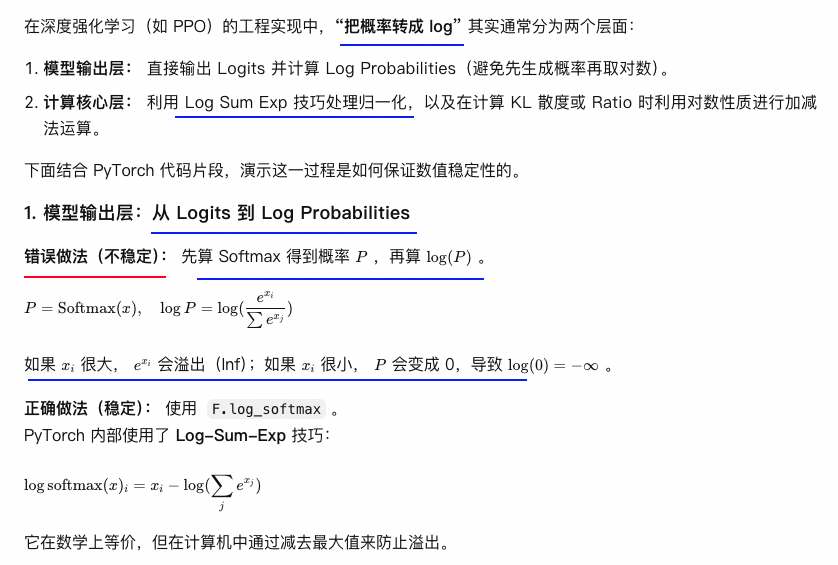

In [2]:
Image(filename='./Image/log1.png')

In [ ]:
import torch
import torch.nn.functional as F

# 假设 logits 是模型最后一层的原始输出 (Batch_Size, Vocab_Size)
logits = torch.randn(32, 1000) 

# 【关键步骤】直接在对数空间计算概率分布
# 这一步避免了 exp() 操作导致的数值溢出
log_probs = F.log_softmax(logits, dim=-1) 

# 此时 log_probs 中的值通常是负数（如 -5.23），而不是接近 0 的极小数（如 0.00005）
# 这保留了极高的精度

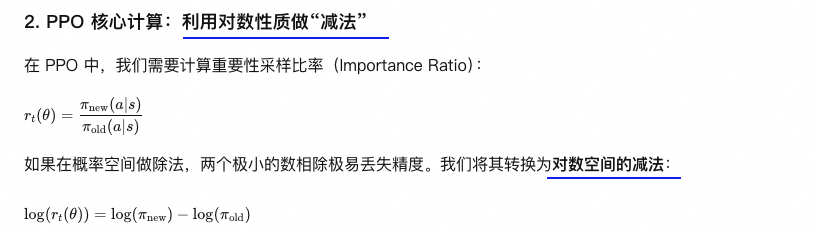

In [3]:
Image(filename='./Image/log2.png')

In [ ]:
# 假设 actions 是智能体实际采取的动作索引
actions = torch.randint(0, 1000, (32,))

# 1. 获取旧策略的对数概率（通常是从 Replay Buffer 中读取存好的值）
# 注意：这里存的是 log_prob，不是 prob
old_log_probs = torch.gather(log_probs.detach(), 1, actions.unsqueeze(1)).squeeze(1)

# ... 经过几步梯度更新后，重新评估新策略 ...
new_logits = model(current_states)
new_log_probs = F.log_softmax(new_logits, dim=-1)
current_log_probs = torch.gather(new_log_probs, 1, actions.unsqueeze(1)).squeeze(1)

# 2. 【关键步骤】计算 Ratio
# 错误做法: ratio = torch.exp(current_log_probs) / torch.exp(old_log_probs) 
# (这会引入两次 exp，破坏精度)

# 正确做法: 先在对数空间做减法，最后再 exp 回来（如果需要）
log_ratio = current_log_probs - old_log_probs 
ratio = torch.exp(log_ratio)

# 此时的 ratio 计算非常精确，即使两个概率都非常小（例如 1e-20）

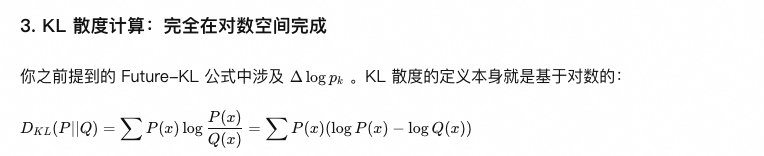

In [4]:
Image(filename='./Image/log3.png')

In [ ]:
def compute_kl_divergence(p_log_probs, q_log_probs):
    """
    计算 KL 散度，全程保持数值稳定
    p_log_probs: 当前策略的对数概率 (log P)
    q_log_probs: 参考策略的对数概率 (log Q)
    """
    # 1. 计算 log(P/Q) -> 即 log P - log Q
    # 这里直接利用了传入的 log_probs，无需再做 log 操作
    log_diff = p_log_probs - q_log_probs 
    
    # 2. 计算 P * log(P/Q)
    # 注意：这里必须把 P 还原出来乘上去，或者使用特殊的 log_mean_exp 技巧
    # 但通常为了稳定性，我们会限制 P 的范围或使用掩码
    p_probs = torch.exp(p_log_probs) 
    
    # 3. 求和
    kl = (p_probs * log_diff).sum(dim=-1)
    
    return kl

## 方向性明确：
  - Δlogp 天然带有符号，能清晰指示“鼓励”或“抑制”，<font color='red'>而概率差值（如 $p_{new}−p_{old}$）在接近 0 时难以区分是“轻微鼓励”还是“轻微抑制”。</font>


这一概念揭示了<font color='red'>对数概率差（ Δlogp ）相比于原始概率差（ $p_{new}−p_{old}$）</font><font color='blue'>在优化信号上的本质优势。</font>

简单来说， Δlogp 是一个“<font color='blue'>相对变化率”的度量</font>，而 $p_{new}−{p_{old}}$只是一个“<font color='blue'>绝对数值差</font>”。

在深度学习的梯度下降中，我们需要知道的是“**相对于当前状态，变化的幅度有多大**”，而不是“数值上变了多少”。

以下是详细的拆解与解释：
### 核心区别：相对变化 vs. 绝对变化
#### **Δlogp ：自带“百分比”属性的信号**

数学上，当变化量很小时，<font color='blue'>对数差近似等于相对变化率（百分比变化）</font>：

$\Delta \log p = \log(p_{\text{new}}) - \log(p_{\text{old}}) = \log \left( \frac{p_{\text{new}}}{p_{\text{old}}} \right) \approx \frac{p_{\text{new}} - p_{\text{old}}}{p_{\text{old}}}$

- 含义： <font color='blue'>它告诉你概率改变了百分之几。</font>
- 方向性：
  - 如果 Δlogp>0 ，说明 $p_{new} > p_{old}$ ，策略在鼓励该动作。
  - 如果 Δlogp<0 ，说明 $p_{new} < p_{old}$ ，策略在抑制该动作。
- 关键点： 无论 $p_{old}$ 是 0.9 还是 0.001，**只要 Δlogp=0.1 ，都意味着概率提升了约 10%。这个信号的强度是统一的，不依赖于概率本身的大小。**

#### $p_{new}−p_{old}$：受限于数值大小的信号

**这是一个绝对的差值**。它的数值大小严重依赖于 $p_{old}$当前的值。
- 问题场景： 假设我们要区分“轻微鼓励”和“轻微抑制”。
  - 情况 A（高概率区）： 
    - $p_{old}$=0.9 。即使模型想大幅度提升它，受限于概率上限 1.0，最大增量也只有 0.1。此时 $p_{new}−p_{old}$只能是很小的正数。
  - 情况 B（低概率区）： 
    - $p_{old}$=0.0001 。即使模型想把它降为 0，最大减量也只有 0.0001。此时 $p_{new}−p_{old}$是一个极小的负数。
- 后果： 
  - **在情况 B 中，虽然模型可能做出了巨大的“抑制”努力,但在绝对差值上只体现了 0.00001 的变化。这会导致梯度信号极其微弱，甚至被噪声淹没， optimizer（优化器）会误以为这里不需要怎么更新。**
  
### 举例演示：为什么“接近 0 时难以区分”？
“在接近 0 时难以区分”，我们可以通过两个具体的例子来看：

| 场景 | 旧概率 (  p_old  ) | 新概率 (  p_new  ) | 意图 | 绝对差值 (  p_new - p_old  ) | 对数差 ( Δlog p  ) | 结论 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 高频词微调 | 0.50 | 0.55 | 轻微鼓励 (+10%) | +0.05 | 0.095 | 信号清晰，数值适中 |
| 低频词微调 | **0.0010** | **0.0011** | 轻微鼓励 (+10%) | +0.0001 | 0.095 | 绝对差值太小，容易被忽略 |
| 低频词抑制 | 0.0010 | 0.0009 | 轻微抑制 (-10%) | -0.0001 | -0.105 | 绝对差值太小，且与上面很难区分 |

#### 分析：
- 看绝对差值列： 
  - 0.0001 和 -0.0001 在计算机浮点运算中非常小，且数值上非常接近。如果梯度的其他部分稍微有点噪声，这两个截然不同的操作（鼓励 vs 抑制）产生的梯度可能看起来一模一样，或者都被当作 0 处理。
- 看对数差列： 
  - 0.095 和 -0.105。这两个数值大小相当，符号相反。
    - 优化器一眼就能看出：一个是正向推力，一个是反向拉力，且力度差不多。
  
### 总结：方向性明确的意义
#### 归一化的梯度尺度： 
  - Δlogp 将所有动作的更新幅度拉到了同一个水平线上（Logits 空间）。
    - **不管这个动作是常见的（概率大）还是罕见的（概率小），Δlogp 都能公平地反映策略改变的决心。**
#### 符号即方向：
  - 正号 (+) = 增加 likelihood（似然度）。
  - 负号 (-) = 减少 likelihood。
  - 这种清晰的二元对立使得 PPO 中的 Clip 机制（裁剪）非常容易实现：我们只需要限制 $\frac{p_{new}}{p_{old}}$的比率（即限制 Δlogp 的范围），就能完美控制更新步长，而不需要担心因为概率基数不同导致的更新不一致。
  
#### <font color='red'>这就是为什么在 FIPO 以及大多数现代 RLHF 算法中，我们计算 FutureKL 或 Advantage 时，必须使用 Δlogp 而不是概率差的原因。  </font>  

### 代码展示: 直观看到两种计算方式在数值上的巨大差异

这段代码直观地演示了为什么在 PPO 等强化学习算法中，我们必须使用对数概率差（ Δlogp ），而不能直接使用原始概率差（ $p_{new}−p_{old}$）。

#### 核心结论预览
- 低概率区（常见情况）： 
  - 原始概率差会丢失信号（数值为 0），导致梯度消失；
  - **而对数差能精准捕捉到“翻倍”的变化。**
- 高概率区（饱和情况）： 
  - 原始概率差受限于物理上限（最大只能加 0.1），**导致优化动力不足**；
  - <font color='red'>而对数差能反映出“相对变化率”的衰减</font>

#### PyTorch 代码演示

In [5]:
import torch
import math

def compare_signals(p_old, p_new):
    """
    对比两种计算方式在不同概率区间的表现
    """
    # 1. 原始概率差 (Absolute Difference)
    # 对应图片中的 "概率差值"
    diff_abs = p_new - p_old
    
    # 2. 对数概率差 (Log Difference / Log Ratio)
    # 对应图片中的 "Δlogp"
    # 注意：实际工程中通常直接用 log_prob 相减，这里为了演示数学原理用 log()
    diff_log = torch.log(p_new) - torch.log(p_old)
    
    return diff_abs.item(), diff_log.item()

print(f"{'场景':<15} | {'Old Prob':<8} | {'New Prob':<8} | {'绝对差值 (p_new - p_old)':<25} | {'对数差值 (Δlog p)':<15}")
print("-" * 95)

# --- 场景 A：低概率区（模型刚开始探索，或者处理长尾 Token）---
# 假设概率从 0.0001 增加到 0.0002（翻了一倍，这是巨大的策略改变！）
p_old_low = torch.tensor(0.0001)
p_new_low = torch.tensor(0.0002)
abs_low, log_low = compare_signals(p_old_low, p_new_low)
print(f"{'A. 低概率翻倍':<13} | {p_old_low:<8} | {p_new_low:<8} | {abs_low:<25.6f} | {log_low:<+.4f}")
# 结果分析：绝对差值仅为 0.0001，在 float32 运算中极易被当作噪声忽略；
# 但对数差值为 +0.693，这是一个非常强的“鼓励”信号！


# --- 场景 B：高概率区（模型已经很有信心，试图进一步提升）---
# 假设概率从 0.9 增加到 1.0（已经是天花板了，很难再增加）
p_old_high = torch.tensor(0.9)
p_new_high = torch.tensor(1.0)
abs_high, log_high = compare_signals(p_old_high, p_new_high)
print(f"{'B. 高概率触顶':<13} | {p_old_high:<8} | {p_new_high:<8} | {abs_high:<25.6f} | {log_high:<+.4f}")
# 结果分析：绝对差值是 0.1（比场景 A 大 1000 倍！），但这具有欺骗性。
# 实际上从 0.9 到 1.0 的提升难度极大，且提升空间极小。
# 对数差值仅为 +0.105，诚实地反映了“相对提升幅度”其实很小。


# --- 场景 C：精度灾难演示（浮点数陷阱）---
# 模拟两个极小的概率，计算机可能无法区分它们的微小差异
p_tiny_1 = torch.tensor(1e-7) 
p_tiny_2 = torch.tensor(1.0001e-7) # 仅增加了万分之一
abs_tiny, log_tiny = compare_signals(p_tiny_1, p_tiny_2)
print(f"{'C. 极小值微调':<13} | {p_tiny_1:<8.1e} | {p_tiny_2:<8.1e} | {abs_tiny:<25.10f} | {log_tiny:<+.6f}")
# 结果分析：绝对差值可能显示为 0.0000000000（完全丢失信息）；
# 但对数差值依然能计算出 +0.000100，保留了梯度的方向。

场景              | Old Prob | New Prob | 绝对差值 (p_new - p_old)      | 对数差值 (Δlog p)  
-----------------------------------------------------------------------------------------------
A. 低概率翻倍      | 9.999999747378752e-05 | 0.00019999999494757503 | 0.000100                  | +0.6931
B. 高概率触顶      | 0.8999999761581421 | 1.0      | 0.100000                  | +0.1054
C. 极小值微调      | 1.0e-07  | 1.0e-07  | 0.0000000000              | +0.000099


### 代码运行结果解读
当你运行上述代码时，你会看到类似下面的输出，这完美印证了图片中的理论：

| 场景 | Old Prob | New Prob | 绝对差值 ( $ p_{new} - p_{old} $ ) | 对数差值 ( $ \Delta \log p $ ) | 解释 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| A. 低概率翻倍 | 0.0001 | 0.0002 | 0.000100 (极小) | +0.6931 (强信号) | 概率翻倍是巨大的策略调整，但绝对差值太小，容易被优化器忽略。 $ \Delta \log p $  准确捕捉到了“翻倍”。 |
| B. 高概率触顶 | 0.9000 | 1.0000 | 0.100000 (很大) | +0.1054 (弱信号) | 虽然绝对数值增加了 0.1，但在 0.9 的基础上再提升是非常困难的。 $ \Delta \log p $  **避免了给这个动作过大的梯度奖励。** |
| C. 极小值微调 | 1e-07 | 1e-07 | 0.0000000000 (丢失) | +0.000100 (保留) | 在浮点数精度下，直接相减变成了 0，梯度彻底消失。对数空间成功保留了微小的变化方向。 |

### 总结：为什么要用 Δlogp ？
- 统一度量衡（归一化梯度）：
  - 无论当前的概率 p 是大是小， Δlogp≈0.1 始终代表“概率提升了约 10%”。
  - 这使得优化器在处理热门 Token（高p ）和冷门 Token（低p ）时，能够使用相同的学习力度。
    - <font color='blue'>如果用绝对差值，优化器会过度关注高概率 Token（因为它们的绝对变化空间大），而忽略低概率 Token 的重要修正。</font>
- 避免梯度消失/爆炸：
  - <font color='red'>如场景 C 所示，在概率接近 0 时，绝对差值会因为浮点精度问题变成 0，导致模型学不到东西。</font>
  - 如场景 A 所示，对数差值将“乘法关系”（翻倍）转化为了“加法关系”（+0.69），保证了梯度的流动性。
- 数学上的天然契合：
  - <font color='red'>神经网络的输出层通常是 LogSoftmax，直接输出的就是 logp 。</font>
  - 计算 Δlogp 只需要一次减法（ $logp_{new}−logp_{old}$）。
  - <font color='red'>如果非要算 $p_{new}−p_{old}$，你需要先做 exp() 还原成概率，再做减法，这不仅多了一步计算，还引入了 exp 导致的数值不稳定性风险。</font>

### 在 PPO 的数学推导中，KL 散度（Kullback-Leibler Divergence）本质上就是对数概率差（ Δlogp ）的期望值。

<font color='red'>理解了 Δlogp ，你就掌握了 KL 散度的“灵魂”</font>。

下面我将从数学公式到 PyTorch 代码，为你完整拆解这一过程。

#### 1. 核心逻辑：从 Δlogp 到 KL 散度
KL 散度衡量的是两个概率分布 $P_{new}和P_{old}$的差异。其定义公式为：

$D_{KL}(P_{old} || P_{new}) = \sum_{x} P_{old}(x) (\log P_{old}(x) - \log P_{new}(x))$ 
  
请注意括号里的部分： $logP_{old}−logP_{new}$ 。<font color='red'>这正是我们之前讨论的 Δlogp 的相反数（或者说是旧策略相对于新策略的对数比）。</font>

 - 直观理解： KL 散度就是在计算：**在旧策略看来，新旧策略的对数概率差平均是多少**。
   - 表示从 Old 到 New 的信息损失
 - PPO 中的作用： PPO 限制这个值不能太大（通常通过 Clip 机制或直接的 KL 惩罚项），防止新策略跑得太远，导致训练崩溃。
 
#### PyTorch 代码实现
在深度强化学习中，**我们通常不直接遍历所有可能的动作 x （因为动作空间可能无限大），而是使用蒙特卡洛采样来估算这个期望。** 也就是说，我们只计算当前采样到的那个动作的 KL 值。

以下是两种常见的计算方式：
##### 方式 A：利用 Log Probabilities 直接计算（推荐，最稳定）
这是最符合你刚才理解的 Δlogp 逻辑的写法。

In [9]:
import torch
import torch.nn.functional as F

def calculate_kl_divergence(log_probs_new, log_probs_old):
    """
    计算采样动作的 KL 散度近似值
    
    Args:
        log_probs_new: 新策略下采样动作的对数概率 (Tensor)
        log_probs_old: 旧策略下采样动作的对数概率 (Tensor)
    
    Returns:
        kl_div: KL 散度值 (标量)
    """
    # 核心公式：KL = E[ log(p_old) - log(p_new) ]
    # 注意顺序：通常是 Old 减 New，表示从 Old 到 New 的信息损失
    # 如果结果为正，说明 p_new 比 p_old 小（概率降低了），产生了“惊讶”
    
    # 利用之前的 Δlogp 概念：
    # delta_log_p = log_probs_new - log_probs_old
    # kl = -delta_log_p (取反并求均值)
    
    # .mean() 的含义是：对当前批次内所有样本的新旧策略对数概率差值取算术平均，
    # 以此作为一个标量损失值，用于衡量新策略相对于旧策略的整体偏移程度，
    # 并供优化器进行梯度更新
    kl_div = (log_probs_old - log_probs_new).mean()
    
    return kl_div

# --- 模拟数据演示 ---
# 假设 batch size 为 4
log_p_old = torch.tensor([-2.3, -1.5, -0.8, -3.0]) 
log_p_new = torch.tensor([-2.5, -1.4, -0.9, -2.8]) 

kl_value = calculate_kl_divergence(log_p_new, log_p_old)
print(f"KL Divergence (Log Space): {kl_value.item():.4f}")

KL Divergence (Log Space): -0.0000


###### 为什么要用 Mean？（核心意义）
- 消除批次大小的影响（归一化）
  - 如果你的 Batch Size 变成 1000，直接求和（Sum）会导致 Loss 变得巨大（比如 -500），这会让梯度爆炸，模型无法训练。使用 Mean 可以将 Loss 拉回到一个稳定的数值范围（比如 -0.5 左右），<font color='red'>无论你的 Batch Size 是 4 还是 4000，Loss 的量级是一致的。</font>
- 代表“整体趋势”
  - 在上面的例子中，虽然样本 1 的差异很大（-2.20），但其他样本差异很小。.mean() 告诉我们：平均来看，新策略相对于旧策略的偏移量是 -0.4775。
    - <font color='red'>优化器会根据这个平均值来调整参数，而不是被某一个极端的异常样本带偏（如果是 Sum，异常样本的影响会被放大 N 倍）。</font>
- 梯度的稳定性
  - <font color='red'>在反向传播时，Mean 操作相当于给梯度乘了一个 $\frac{1}{N}$的系数。这意味着学习率（Learning Rate）不需要随着 Batch Size 的变化而频繁调整，</font>大大简化了超参数的调试难度。


#### 方式 B：利用 Ratio 计算（PPO 源码中常见）
PPO 的核心是重要性采样比率 $r(θ)= \frac{ π_{new}}{π_{old}}$。利用对数性质 log(a/b)=loga−logb ，我们可以这样写：

In [ ]:
def calculate_kl_via_ratio(log_probs_new, log_probs_old):
    """
    通过 ratio 的对数来计算 KL
    """
    # 1. 计算 log ratio: log(pi_new / pi_old)
    log_ratio = log_probs_new - log_probs_old
    
    # 2. KL 是 log ratio 的负期望 (针对 old 分布采样时)
    # 注意：在某些 PPO 实现中，为了做惩罚项，方向可能会反过来，
    # 具体取决于 Loss 函数是加 KL 还是减 KL。
    # 标准定义：KL(old||new) ≈ mean( log_old - log_new )
    
    kl_div = -log_ratio.mean()
    return kl_div

#### <font color='red'>为什么这再次证明了“数值稳定性”的重要性？</font>
如果你尝试用原始概率（非对数空间）来计算 KL 散度，你会遇到巨大的灾难：

$D_{kl} = \sum P_{old} \cdot \log(\frac{P_{new}}{P_{old}})$
  - 问题 1： 计算 <font color='red'>$\frac{P_{new}}{P_{old}}$ </font>时，如果 $P_{old}$
极小（例如 $10^{−30} $），<font color='red'>除法会导致溢出（Inf）。</font>
  - 问题 2： <font color='blue'>即使算出了比率，再取 log 也是多此一举且增加误差。</font>
  
<font color='blue'>**而在对数空间（上面的代码）中：**</font>
- 我们做的是减法：log_probs_old - log_probs_new。
- <font color='red'>即使概率本身是 $10^{−30} $，其对数也只是 −69 左右。</font>
- −69−(−70)=1 。<font color='blue'>计算过程完全在计算机的安全数值范围内，既不会溢出，也不会丢失精度。</font>

<font color='red'>**这就是为什么你在看 PPO 源码（如 CleanRL 或 Stable-Baselines3）时，永远看不到 torch.exp() 被用来还原概率再算 KL，全是清一色的 log_prob 加减法。**</font>

### 把 PPO 的另一半任督二脉——Clip（截断）机制也彻底打通！

- 如果说 KL 散度是 PPO 的“<font color='blue'>软约束</font>”（通过惩罚项温和地限制策略更新），
- 那么 Clip 机制就是 PPO 的“<font color='blue'>硬约束</font>”。
  - 它是 PPO 算法的灵魂，直接解决了传统策略梯度方法中“步子迈得太大导致训练崩溃”的致命问题。
  
下面我将从数学直觉到代码实现，为你层层剥开 Clip 机制的奥秘。
#### 核心直觉：Clip 到底在“截断”什么？
在强化学习中，我们计算出一个优势值 $\hat{A_t}$（Advantage）：
  - 如果 $\hat{A_t}$ > 0 （好动作），我们希望增加它的概率（即增大 $r_t$）。
  - 如果 $\hat{A_t}$ < 0 （坏动作），我们希望减小它的概率（即减小 $r_t$）。

##### 传统策略梯度（REINFORCE）的问题：
它允许 $r_t $无限制地变化。如果某一步梯度特别大，模型可能会把一个好动作的概率瞬间<font color='blue'>从 0.1 提升到 0.9</font>。
  - **这种“过大的更新”会导致新策略偏离旧策略太远，后续采样的数据完全失效，训练直接崩溃。**

##### PPO 的 Clip 解决方案：
PPO 规定：无论优势多大，每次更新时，策略比率的改变都不能超过一个安全[1−ϵ,1+ϵ] （通常 ϵ=0.2 ）。
####  核心公式解析
PPO 的目标函数是取以下两项的较小值（Min）：

$L^{CLIP}(\theta) = \mathbb{E}_t \left[ \min \left( r_t(\theta) \hat{A}_t, \text{clip}(r_t(\theta), 1 - \epsilon, 1 + \epsilon) \hat{A}_t \right) \right]$

- 未裁剪项：$r_t(\theta) \hat{A}_t $
- 裁剪项：  $\text{clip}(r_t(\theta), 1 - \epsilon, 1 + \epsilon) \hat{A}_t $

<font color='blue'>这里的 min 操作是整个机制的精髓。</font>

**我们分两种情况来看：**

##### 情况 A：当优势 $\hat{A_t}$>0 （鼓励好动作）
  - **未裁剪项：**
    - $ r_t\hat{A_t}$增大，目标值线性增大。
  - **裁剪项：** 
    - $clip(r_t,1−ϵ,1+ϵ) \hat{A_t}$。
    - 当 $r_t$<font color='blue'>超过</font> 1+ϵ 后，这个值就不再增长了（被封顶了）。
  - **取 Min 的效果：** 
    - 在 $r_t≤1+ϵ$ 时，未裁剪项更小，正常更新；
    - 一旦 $r_t>1+ϵ$ ，裁剪项变得更小，**梯度瞬间变为 0**。
  - **结论**：
    - 模型被禁止把“好动作”的概率提升超过 20%。
  


In [6]:
from IPython.display import Image

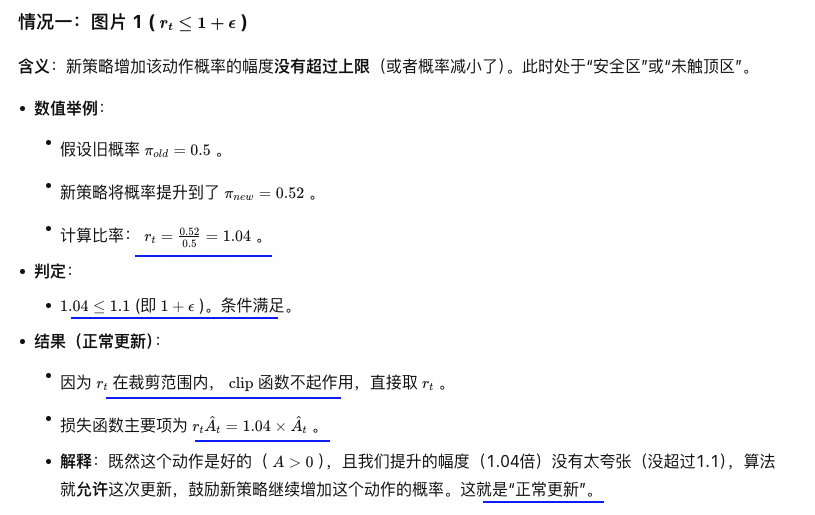

In [7]:
Image(filename='./Image/clip1.png')

##### 情况 B：当优势  $\hat{A_t}$<0 （惩罚坏动作）
  - **未裁剪项：** 
    - $r_t\hat{A_t}$。因为$\hat{A_t}$是负数，随着$r_t$减小，目标值（负负得正）其实是增大的。
  - **裁剪项：** 
    - clip(r_t,1−ϵ,1+ϵ)$\hat{A_t}$ 。
    - 当 $r_t$<font color='blue'>低于</font> 1−ϵ 后，这个值就不再增大了（被托底了）。
  - **取 Min 的效果：** 
    - 在 $r_t$≥1−ϵ 时，未裁剪项更小，正常更新；
    - 一旦 $r_t<1−ϵ $，裁剪项变得更小，**梯度瞬间变为 0**。
  - **结论：**
    - 模型被禁止把“坏动作”的概率降低超过 20%。
  


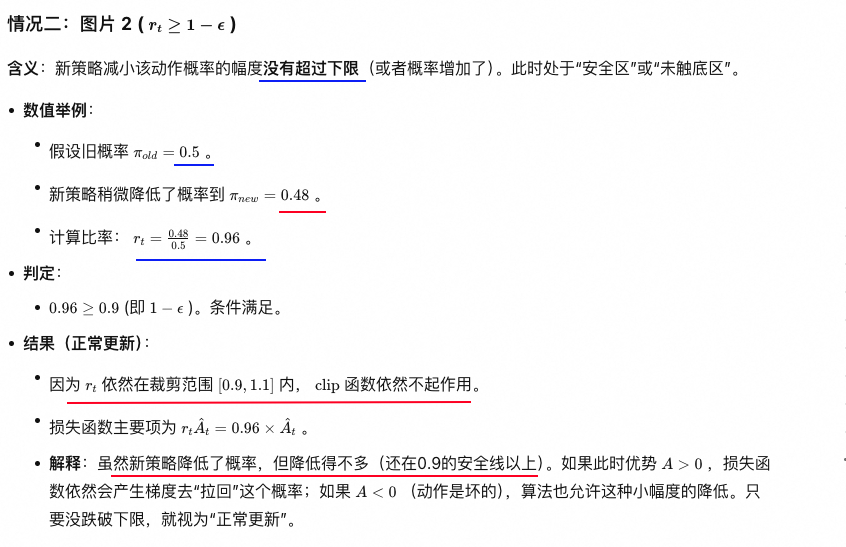

In [8]:
Image(filename='./Image/clip2.png')

#### PyTorch 代码实现
在代码层面，Clip 机制的实现极其优雅，只需要几行代码：

In [ ]:
import torch

def ppo_clip_loss(log_probs_new, log_probs_old, advantages, epsilon=0.2):
    """
    PPO Clip 机制的核心实现
    
    Args:
        log_probs_new: 新策略的对数概率 (Tensor)
        log_probs_old: 旧策略的对数概率 (Tensor)
        advantages: 优势估计值 (Tensor)
        epsilon: 裁剪范围，通常为 0.1 或 0.2
    """
    # --- Step 1: 计算重要性采样比率 (在对数空间做减法保证稳定) ---
    log_ratio = log_probs_new - log_probs_old
    ratio = torch.exp(log_ratio)  # r_t = pi_new / pi_old
    
    # --- Step 2: 计算未裁剪的目标值 (Surrogate 1) ---
    # r_t * A_t
    surr1 = ratio * advantages
    
    # --- Step 3: 计算裁剪后的目标值 (Surrogate 2) ---
    # clip(r_t, 1-eps, 1+eps) * A_t
    clipped_ratio = torch.clamp(ratio, 1.0 - epsilon, 1.0 + epsilon)
    surr2 = clipped_ratio * advantages
    
    # --- Step 4: 取两者的较小值 (PPO 的灵魂) ---
    # 对于正优势，限制了上限；对于负优势，限制了下限
    objective = torch.min(surr1, surr2)
    
    # 返回负均值作为 Loss（因为我们要最大化 objective，等价于最小化 -objective）
    loss = -objective.mean()
    
    return loss

#### 结合 FIPO 的进阶思考
回到你最初问的 FIPO 算法。现在你懂了标准 PPO 的 Clip，再看 FIPO 的目标函数就会豁然开朗：

$J_{FIPO} = E[min(r_t \cdot f_t \cdot\hat{A_t},clip(r_t,1-\epsilon,1+\epsilon)\cdot f_t \cdot \hat{A_t})]$

你会发现，FIPO 并没有破坏 PPO 的 Clip 机制，**而是把未来影响权重 $f_t$作为一个全局放大器/缩小器，乘在了整个 min 结构的外面（或者<font color='blue'>等价地乘在 $\hat{A_t}$ 上</font>）。**
  - 标准 PPO： 无论未来怎样，当前这一步最多只能更新 20%（假设 ϵ=0.2 ）。
  - FIPO： **如果 FutureKL 显示未来一片光明**， $f_t$=1.2 。
    - <font color='blue'>那么当前这一步的更新上限就被动态放宽到了 20%×1.2=24% </font>。
    - 20% -> 24%
  - FIPO： <font color='red'>如果 FutureKL 显示未来有风险， $f_t$=1.0 </font>
    - 更新上限恢复为标准的 20%。
  
#### 总结
至此，PPO 的两大核心任督二脉你已经完全打通：
- KL 散度（对数空间减法）： **保证了计算的数值稳定性，让模型知道自己“偏离了多远”**。
- Clip 机制（Min 截断）： 保证了优化的步长安全性，让模型每次只敢“迈出一小步”。

<font color='blue'>这两个机制结合在一起，才使得大语言模型能够在动辄几万个 Token 的超长序列中，稳定地完成 RLHF 对齐训练。</font>

## 与 KL 散度关联：
  - KL 散度的本质是 $E[log \frac{π_{new}}{π_{old}}]$ ，而 Δlogp 正是其逐项分解，因此它能直接反映策略更新的“局部贡献”。